In [1]:
import os
import pandas as pd
import numpy as np
import glob
import math
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.optimizers import Adam # Using standard Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.utils.class_weight import compute_class_weight

2025-05-13 02:44:40.948165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747104281.352695      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747104281.472716      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
KAGGLE_DATASET_SLUG='hb1ac-dataset'
KAGGLE_INPUT_DIR=f'/kaggle/input/hb1ac-dataset'


In [3]:
# Fallback for local execution if Kaggle environment not present
if not os.path.exists(KAGGLE_INPUT_DIR):
    print(f"Warning: Kaggle input directory '{KAGGLE_INPUT_DIR}'not found.")
# TRY TO POINT TO A LOCAL DIRECTORY IF YOU HAVE THE DATA DOWNLOADED
# For example, if your script is in a project folder, and 'hb1ac-dataset' is a subfolder:
    KAGGLE_INPUT_DIR='./hb1ac-dataset' 
    if not os.path.exists(KAGGLE_INPUT_DIR):
        print(f"CRITICAL: Local fallback directory'{KAGGLE_INPUT_DIR}'also not found.")
        print("Please ensure your data is in the correct local path or you are running on Kaggle.")
# Create dummy structure for script to run through further for structural checks
# but training will fail without real data.
        try:
            os.makedirs(os.path.join(KAGGLE_INPUT_DIR, 'DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF'), exist_ok=True)
            os.makedirs(os.path.join(KAGGLE_INPUT_DIR, 'DM/DM(HbA1c) Images/DM(HbA1c_FF)images/HbA1c_FF'), exist_ok=True)
            os.makedirs(os.path.join(KAGGLE_INPUT_DIR, 'DM/DM with HbA1C (Values)'), exist_ok=True)
            print("Created dummy local directory structure for hb1ac-dataset for testing.")
        except Exception as e_mkdir:
            print(f"Could not create dummy directories: {e_mkdir}")
    else:
        print(f"Using local directory for data:'{KAGGLE_INPUT_DIR}'")


In [4]:
#  2. Model Parameters 
IMG_SIZE = 260
BATCH_SIZE = 16
BUFFER_SIZE = tf.data.AUTOTUNE
N_CLASSES_OUTPUT_NEURONS = 1
LEARNING_RATE_INITIAL = 1e-3 # Common effective LR
LEARNING_RATE_FINETUNE_START = 5e-5 # Common effective LR for fine-tuning
EPOCHS_INITIAL = 20
EPOCHS_FINETUNE = 40
TOTAL_EPOCHS_COMBINED = EPOCHS_INITIAL + EPOCHS_FINETUNE
RANDOM_SEED = 42
HBA1C_THRESHOLD = 6.5
CLASS_NAMES_BINARY = [f'<= {HBA1C_THRESHOLD} (0)', f'> {HBA1C_THRESHOLD} (1)']

# Set random seeds
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
# --- 3.1. Data Paths (Using your provided structure) ---
hf_image_dir = os.path.join(KAGGLE_INPUT_DIR, 'DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF') # Path from your input
ff_image_dir = os.path.join(KAGGLE_INPUT_DIR, 'DM/DM(HbA1c) Images/DM(HbA1c_FF)images/HbA1c_FF') # Path from your input
excel_dir = os.path.join(KAGGLE_INPUT_DIR, 'DM/DM with HbA1C (Values)')
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg')

In [6]:
# Binary Focal Loss Definition (Revised)
def binary_focal_loss_revised(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, dtype=tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred) # Prob for true class
        alpha_factor = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha) # Alpha for true class
        modulating_factor = tf.pow(1.0 - p_t, gamma)
        cross_entropy_term = -tf.math.log(p_t + epsilon) # Corrected: added negative sign
        focal_loss = alpha_factor * modulating_factor * cross_entropy_term
        return tf.reduce_sum(focal_loss) # Or reduce_mean, depends on desired behavior / context
    return focal_loss_fixed

In [7]:
# --- Step 1 (from your original numbering): Consolidate Labels from Excel Files ---
print("--- Step 1: Consolidating Labels ---")
def get_image_basenames_quiet(list_of_image_dirs_param):
    basenames = set()
    for img_dir_path in list_of_image_dirs_param:
        if not os.path.isdir(img_dir_path):
            print(f"Warning: Image dir not found: {img_dir_path}")
            continue
        for filename in os.listdir(img_dir_path):
            if filename.lower().endswith(IMAGE_EXTENSIONS):
                basenames.add(os.path.splitext(filename)[0])
    return basenames

image_basenames = get_image_basenames_quiet([hf_image_dir, ff_image_dir])
print(f"Total unique image basenames found: {len(image_basenames)}")

excel_file_configs = [
    {'filename': 'DM_Blood sugar_Feb22.xlsx', 'sheet_name': 'Sheet2', 'id_col': 'SI NO', 'hba1c_col': 'HbA1C'},
    {'filename': 'DM_Blood sugar_Feb4.xlsx', 'sheet_name': 'Sheet1', 'id_col': 'SI NO', 'hba1c_col': 'HbA1C'},
    {'filename': 'DM_Blood sugar_Dec13.xlsx', 'sheet_name': 'Sheet4', 'id_col': 'SI NO', 'hba1c_col': 'HbA1C '}, # Note space
    {'filename': 'DM_Blood sugar_New.xlsx', 'sheet_name': 'HbA1c(HF)', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood sugar_New.xlsx', 'sheet_name': 'HbA1c(FF)', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood sugar_Oct21.xlsx', 'sheet_name': 'HbA1c(HF)', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood sugar_Oct21.xlsx', 'sheet_name': 'HbA1c(FF)', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood sugar_Oct29.xlsx', 'sheet_name': 'HbA1c(HF)', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood sugar.xlsx', 'sheet_name': 'Sheet1', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'},
    {'filename': 'DM_Blood Sugar_Dec24.xlsx', 'sheet_name': 'Sheet1', 'id_col': 'SI NO', 'hba1c_col': 'HbA1c'}
]

all_label_data = []
final_labeled_data = pd.DataFrame(columns=['image_id', 'hba1c_value']) # Initialize default

if not os.path.isdir(excel_dir):
    print(f"CRITICAL: Excel directory not found: {excel_dir}. Cannot load labels.")
else:
    for config in excel_file_configs:
        file_path = os.path.join(excel_dir, config['filename'])
        if not os.path.exists(file_path):
            print(f"Warning: Excel file not found: {file_path}")
            continue
        try:
            hba1c_col_cleaned = config['hba1c_col'].strip()
            df_excel = pd.read_excel(file_path, sheet_name=config['sheet_name'])
            df_excel.columns = [str(col).strip() for col in df_excel.columns] # Clean column names robustly
            id_col_cleaned = config['id_col'].strip() # Clean id_col name as well

            if id_col_cleaned not in df_excel.columns or hba1c_col_cleaned not in df_excel.columns:
                print(f"Skipping {config['filename']} ({config['sheet_name']}): missing required columns ('{id_col_cleaned}' or '{hba1c_col_cleaned}')")
                continue
            df_subset = df_excel[[id_col_cleaned, hba1c_col_cleaned]].copy()
            df_subset.rename(columns={id_col_cleaned: 'image_id', hba1c_col_cleaned: 'hba1c_value'}, inplace=True)
            df_subset['image_id'] = df_subset['image_id'].astype(str).str.strip()
            df_subset['hba1c_value'] = pd.to_numeric(df_subset['hba1c_value'], errors='coerce')
            df_subset.dropna(subset=['hba1c_value', 'image_id'], inplace=True)
            if not df_subset.empty:
                all_label_data.append(df_subset)
        except Exception as e:
            print(f"Error processing {config['filename']} ({config['sheet_name']}): {e}")

if not all_label_data:
    print("CRITICAL: No label data extracted. Script will likely fail or produce meaningless results.")
else:
    consolidated_df = pd.concat(all_label_data, ignore_index=True)
    consolidated_df.drop_duplicates(subset=['image_id'], keep='first', inplace=True)
    final_labeled_data = consolidated_df[consolidated_df['image_id'].isin(image_basenames)].copy()
print(f"Final labeled data rows (matching actual images): {len(final_labeled_data)}")

--- Step 1: Consolidating Labels ---
Total unique image basenames found: 912
Final labeled data rows (matching actual images): 912


In [8]:
# --- Step 2 (from your original numbering): Create Binary Class Labels ---
print("\n--- Step 2: Creating Binary Class Labels ---")
def classify_hba1c_binary(value):
    if pd.isna(value): return np.nan
    return 1 if value > HBA1C_THRESHOLD else 0

if 'hba1c_value' in final_labeled_data.columns:
    final_labeled_data['binary_class'] = final_labeled_data['hba1c_value'].apply(classify_hba1c_binary)
    final_labeled_data.dropna(subset=['binary_class'], inplace=True) # Remove rows where binary_class could not be determined
    if not final_labeled_data.empty:
        final_labeled_data['binary_class'] = final_labeled_data['binary_class'].astype(int)
        print(f"Using threshold: {HBA1C_THRESHOLD}. Binary Class distribution:\n{final_labeled_data['binary_class'].value_counts(dropna=False)}")
    else:
        print("Warning: final_labeled_data became empty after creating and dropping NaNs in binary_class.")
else:
    if not final_labeled_data.empty: # Only print warning if data was expected
        print("Warning: 'hba1c_value' column not found in final_labeled_data. Cannot create binary classes.")
    else:
        print("No data to process for binary classes.")



--- Step 2: Creating Binary Class Labels ---
Using threshold: 6.5. Binary Class distribution:
binary_class
0    633
1    279
Name: count, dtype: int64


In [9]:
# --- Step 3 (from your original numbering): Construct Full Image Paths ---
print("\n--- Step 3: Constructing Full Image Paths ---")
def find_image_path(image_id_param, hf_dir_path, ff_dir_path):
    for ext in IMAGE_EXTENSIONS:
        for dir_to_check in [hf_dir_path, ff_dir_path]:
            if not os.path.isdir(dir_to_check): # Check if directory exists
                continue
            path = os.path.join(dir_to_check, f"{image_id_param}{ext}")
            if os.path.exists(path): return path
    return None

if 'image_id' in final_labeled_data.columns:
    final_labeled_data['filepath'] = final_labeled_data['image_id'].apply(lambda x: find_image_path(x, hf_image_dir, ff_image_dir))
    final_labeled_data.dropna(subset=['filepath'], inplace=True) # Remove rows where no image file was found
    print(f"Final dataset size with filepaths: {len(final_labeled_data)}")
else:
    if not final_labeled_data.empty:
        print("Warning: 'image_id' column not found. Cannot construct filepaths.")
    else:
        print("No data to construct filepaths for.")


--- Step 3: Constructing Full Image Paths ---
Final dataset size with filepaths: 912


In [13]:
# --- Step 4 (from your original numbering): Split Data ---
print("\n--- Step 4: Splitting Data ---")
train_df, val_df, test_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame() # Initialize to prevent NameErrors
if len(final_labeled_data) >= 20 and 'binary_class' in final_labeled_data.columns and final_labeled_data['binary_class'].nunique() >= 2:
    train_df, temp_df = train_test_split(final_labeled_data, test_size=0.3, random_state=RANDOM_SEED, stratify=final_labeled_data['binary_class'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_df['binary_class'])
else:
    print("Not enough data or classes to split properly. Using minimal dummy data for script structure testing.")
    dummy_filepaths = [f'dummy_path_{i}.jpg' for i in range(10)]
    dummy_classes = np.random.choice([0,1], 10)
    _dummy_final_data = pd.DataFrame({'filepath': dummy_filepaths, 'binary_class': dummy_classes})
    if len(_dummy_final_data) >=3 and _dummy_final_data['binary_class'].nunique() >= 2:
        train_df, test_df_temp = train_test_split(_dummy_final_data, test_size=0.4, random_state=RANDOM_SEED, stratify=_dummy_final_data['binary_class'])
        if len(test_df_temp) >=2 and test_df_temp['binary_class'].nunique() >= 2 :
            val_df, test_df = train_test_split(test_df_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=test_df_temp['binary_class'])
        elif len(test_df_temp) >= 1 : # If test_df_temp has 1 sample or 1 class
             val_df = test_df_temp.copy() if not test_df_temp.empty else pd.DataFrame(columns=['filepath', 'binary_class'])
             test_df = pd.DataFrame(columns=['filepath', 'binary_class']) # test_df becomes empty
        else: # test_df_temp is empty
            val_df = pd.DataFrame(columns=['filepath', 'binary_class'])
            test_df = pd.DataFrame(columns=['filepath', 'binary_class'])
    else: # _dummy_final_data is too small or has one class
        train_df = _dummy_final_data.copy()
        val_df = pd.DataFrame(columns=['filepath', 'binary_class'])
        test_df = pd.DataFrame(columns=['filepath', 'binary_class'])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


--- Step 4: Splitting Data ---
Train: 638, Val: 137, Test: 137


In [14]:
import cv2

In [15]:
# --- NEW: Flags for enhanced preprocessing ---
APPLY_CLAHE = True
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

APPLY_GAUSSIAN_BLUR = True
GAUSSIAN_BLUR_KERNEL_SIZE = (5, 5) # OpenCV kernel size
GAUSSIAN_BLUR_SIGMA = 0 # Let OpenCV calculate sigma from kernel size, or specify e.g. 1.0

APPLY_ROI_CROP = True # Simple black border cropping
ROI_CROP_THRESHOLD = 15 # Pixels brighter than this are considered non-black



--- Step 5: Building TensorFlow Datasets (ENHANCED) ---


I0000 00:00:1747104538.069696      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747104538.070524      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train C0: 443, C1: 195. Alpha FL for Class 1: 0.25
Calculated class weights: {0: 0.7200902934537246, 1: 1.6358974358974359}
Datasets built with enhanced preprocessing.

Visualizing a few preprocessed training images:


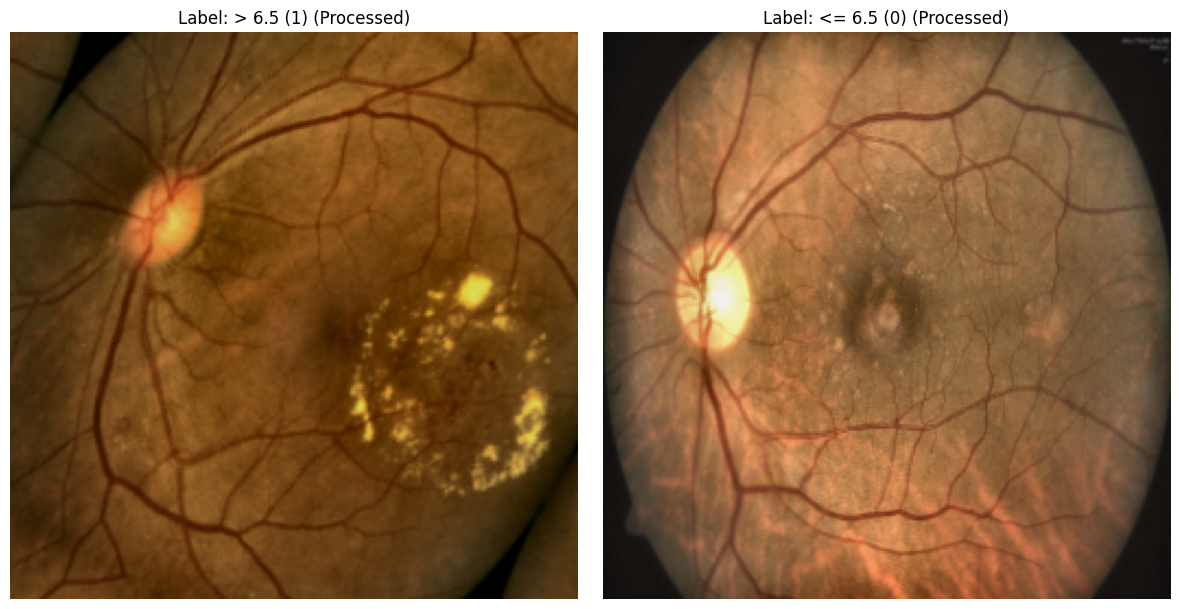

In [16]:
# --- Step 5: Building TensorFlow Datasets (ENHANCED) ---
print("\n--- Step 5: Building TensorFlow Datasets (ENHANCED) ---")

# OpenCV based functions to be wrapped by tf.py_function
def _apply_clahe_cv(image_tensor): # Changed input name for clarity
    image_np = image_tensor.numpy() # <<< FIX: Convert EagerTensor to NumPy array
    # Input image_np is a NumPy array (H, W, C), assumed to be uint8
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_rgb = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_rgb.astype(np.uint8)

def _apply_gaussian_blur_cv(image_tensor): # Changed input name
    image_np = image_tensor.numpy() # <<< FIX: Convert EagerTensor to NumPy array
    # Input image_np is a NumPy array (H, W, C), assumed to be uint8
    return cv2.GaussianBlur(image_np, GAUSSIAN_BLUR_KERNEL_SIZE, GAUSSIAN_BLUR_SIGMA).astype(np.uint8)

def _crop_black_borders_cv(image_tensor): # Changed input name
    image_np = image_tensor.numpy() # <<< FIX: Convert EagerTensor to NumPy array
    # Input image_np is a NumPy array (H, W, C), assumed to be uint8
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY) # This was the failing line
    _, thresh = cv2.threshold(gray, ROI_CROP_THRESHOLD, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_np # No non-black region found, return original

    x_min, y_min = image_np.shape[1], image_np.shape[0]
    x_max, y_max = 0, 0
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)

    if x_max > x_min and y_max > y_min : # Check for valid crop
         return image_np[y_min:y_max, x_min:x_max].astype(np.uint8)
    return image_np # If no valid crop found

data_augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    tf.keras.layers.RandomRotation(0.2, seed=RANDOM_SEED),
    tf.keras.layers.RandomZoom(0.2, seed=RANDOM_SEED),
    tf.keras.layers.RandomContrast(factor=0.2, seed=RANDOM_SEED),
    tf.keras.layers.RandomBrightness(factor=0.2, seed=RANDOM_SEED)
], name="data_augmentation_layer_original")

milder_tta_augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    tf.keras.layers.RandomRotation(0.05, seed=RANDOM_SEED),
    tf.keras.layers.RandomZoom(0.05, seed=RANDOM_SEED)
], name="milder_tta_augmentation_layer_binary_original")


def load_and_preprocess_image(filepath, label):
    try:
        img_str = tf.io.read_file(filepath)
        img_decoded = tf.image.decode_image(img_str, channels=3, expand_animations=False)
        # Ensure img_decoded is uint8 if it's not already (decode_image usually returns uint8)
        if img_decoded.dtype != tf.uint8:
            img_decoded = tf.cast(img_decoded, tf.uint8)

    except tf.errors.NotFoundError:
        try: filepath_str = filepath.numpy().decode()
        except AttributeError: filepath_str = str(filepath)
        print(f"Warning: File not found: {filepath_str}. Using placeholder.")
        img_decoded = tf.zeros([IMG_SIZE, IMG_SIZE, 3], dtype=tf.uint8) # Placeholder
    except Exception as e_decode: # Catch other decoding errors
        print(f"Error decoding image {filepath}: {e_decode}. Using placeholder.")
        img_decoded = tf.zeros([IMG_SIZE, IMG_SIZE, 3], dtype=tf.uint8)


    img_processed = img_decoded

    if APPLY_ROI_CROP:
        img_processed = tf.py_function(func=_crop_black_borders_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])

    if APPLY_CLAHE:
        img_processed = tf.py_function(func=_apply_clahe_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])

    if APPLY_GAUSSIAN_BLUR:
        img_processed = tf.py_function(func=_apply_gaussian_blur_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])

    img_resized = tf.image.resize(img_processed, [IMG_SIZE, IMG_SIZE])
    img_final = tf.cast(img_resized, tf.float32)

    return img_final, tf.cast(label, tf.float32)

def build_dataset(df, shuffle=False, augment=False, augmentation_pipeline=data_augmentation_layer):
    if df.empty or 'filepath' not in df.columns or 'binary_class' not in df.columns:
        return tf.data.Dataset.from_tensor_slices(
            (tf.constant([], dtype=tf.string), tf.constant([], dtype=tf.int32))
        ).batch(BATCH_SIZE).prefetch(BUFFER_SIZE)

    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['binary_class'].values))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    if shuffle: ds = ds.shuffle(buffer_size=max(1, len(df)), seed=RANDOM_SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment: ds = ds.map(lambda x, y: (augmentation_pipeline(x, training=True), y),
                            num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

alpha_for_focal_loss = 0.25
class_weights = None
if not train_df.empty and 'binary_class' in train_df.columns and train_df['binary_class'].nunique() > 0 :
    class_1_count_train = train_df[train_df['binary_class'] == 1].shape[0]
    class_0_count_train = train_df[train_df['binary_class'] == 0].shape[0]
    if (class_0_count_train + class_1_count_train) > 0:
        if class_1_count_train < class_0_count_train: alpha_for_focal_loss = 0.25
        elif class_0_count_train < class_1_count_train: alpha_for_focal_loss = 0.75
        else: alpha_for_focal_loss = 0.5
        print(f"Train C0: {class_0_count_train}, C1: {class_1_count_train}. Alpha FL for Class 1: {alpha_for_focal_loss}")
        if train_df['binary_class'].nunique() > 1:
            unique_classes_train = np.unique(train_df['binary_class'])
            class_weights_array_train = compute_class_weight('balanced', classes=unique_classes_train, y=train_df['binary_class'].values)
            class_weights = dict(zip(unique_classes_train, class_weights_array_train))
            print(f"Calculated class weights: {class_weights}")
        else: print("Only one class present in training data. Cannot compute class weights.")
    else: print("Training data has no samples after filtering. Using default alpha and no class weights.")
else: print("train_df empty, 'binary_class' missing, or no classes. Using default alpha and no class weights.")

train_ds = build_dataset(train_df, shuffle=True, augment=True, augmentation_pipeline=data_augmentation_layer)
val_ds = build_dataset(val_df, shuffle=False, augment=False)
test_ds_no_aug_for_eval = build_dataset(test_df, shuffle=False, augment=False)
print("Datasets built with enhanced preprocessing.")

def show_preprocessing_effect(dataset, num_images=2):
    if isinstance(dataset, tf.data.Dataset):
        # Ensure the dataset isn't empty or fails to produce items
        try:
            # Check if dataset is empty conceptually by trying to get one element
            # This will trigger the pipeline for at least one batch
            # We use list(dataset.take(1)) to materialize it and catch errors early
            batch_list = list(dataset.take(1))
            if not batch_list:
                print("Could not get a batch from the dataset. It might be empty.")
                return
            batch_data = batch_list[0]
        except tf.errors.OutOfRangeError:
            print("Could not get a batch from the dataset (OutOfRangeError). It might be empty.")
            return
        except Exception as e: # Catch any other error during iteration
            print(f"Error fetching batch from dataset for visualization: {e}")
            # You might want to raise e here or log it more extensively for debugging
            return

        images, labels = batch_data

        plt.figure(figsize=(12, num_images * 3)) # Adjusted figure size
        actual_images_to_show = min(num_images, images.shape[0])
        if actual_images_to_show == 0:
            print("Batch contained no images for visualization.")
            return

        for i in range(actual_images_to_show):
            plt.subplot(1, actual_images_to_show, i + 1) # Changed subplot layout for horizontal display
            img_to_show = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
            plt.imshow(img_to_show.numpy()) # .numpy() is needed here for matplotlib
            plt.title(f"Label: {CLASS_NAMES_BINARY[int(labels[i].numpy())]} (Processed)")
            plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("Dataset is not a valid tf.data.Dataset instance.")

print("\nVisualizing a few preprocessed training images:")
if len(train_df) > 0 :
    show_preprocessing_effect(train_ds, num_images=2)
else:
    print("Train_df is empty, cannot visualize.")



In [17]:
# --- Step 6: Focal Loss Alpha ---
print(f"\n--- Step 6: Focal Loss Alpha to be used for Class 1: {alpha_for_focal_loss} ---")


--- Step 6: Focal Loss Alpha to be used for Class 1: 0.25 ---


In [15]:
# --- Step 7: Building Model ---
print("\n--- Step 7: Building Model (or re-compiling if already built) ---")
preprocess_input_effnet = tf.keras.applications.efficientnet.preprocess_input
base_model = EfficientNetB2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling=None)
base_model.trainable = False # Initially freeze the base model

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer")
x = preprocess_input_effnet(inputs) # This is applied AFTER our custom preprocessing
x = base_model(x, training=False)
x = GlobalAveragePooling2D(name="avg_pool")(x)
x = Dropout(0.4, name="top_dropout_1")(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), name="dense_1")(x)
x = Dropout(0.4, name="top_dropout_2")(x)
outputs = Dense(N_CLASSES_OUTPUT_NEURONS, activation='sigmoid', name="predictions")(x)
model = Model(inputs, outputs, name="HbA1c_Retinal_Model") # Added a model name

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_INITIAL),
              loss=binary_focal_loss_revised(gamma=2.0, alpha=alpha_for_focal_loss), # Uses the determined alpha
              metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
model.summary()


--- Step 7: Building Model (or re-compiling if already built) ---
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "HbA1c_Retinal_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 260, 260, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb2 (Functional)          │ (None, 9, 9, 1408)          │       7,768,569 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ avg_pool (GlobalAveragePooling2D)    │ (None, 1408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ top_dropout_1 (Dropout)              │ (None, 1408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         360,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ top_dropout_2 (Dropout)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,129,530 (31.01 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [16]:
# --- Step 8: Setting up Callbacks ---
print("\n--- Step 8: Setting up Callbacks ---")
early_stopping_initial = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True, verbose=1)
reduce_lr_initial = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, mode='min', min_lr=1e-7, verbose=1)

# Define checkpoint_filepath (ensure /kaggle/working exists if on Kaggle, or use local path)
checkpoint_dir = '/kaggle/working/' if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ else './'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_filepath = os.path.join(checkpoint_dir, 'best_binary_model_hba1c_6_5.keras') # Specific name for this threshold

model_checkpoint_initial = ModelCheckpoint(filepath=checkpoint_filepath,
                                           monitor='val_loss',
                                           mode='min',
                                           save_best_only=True,
                                           verbose=1)
callbacks_initial = [early_stopping_initial, reduce_lr_initial, model_checkpoint_initial]
print(f"Checkpoint path for initial training: {checkpoint_filepath}")
print(f"Class weights for model.fit: {class_weights}")


--- Step 8: Setting up Callbacks ---
Checkpoint path for initial training: /kaggle/working/best_binary_model_hba1c_6_5.keras
Class weights for model.fit: {0: 0.7200902934537246, 1: 1.6358974358974359}


In [ ]:
# --- Step 9: Initial Training ---
print("\n--- Step 9: Initial Training (Training the head) ---")
history = None
if not train_df.empty and not val_df.empty:
    # Ensure datasets are not empty and can produce data
    if tf.data.experimental.cardinality(train_ds).numpy() > 0 and \
       tf.data.experimental.cardinality(val_ds).numpy() > 0:
        
        steps_per_epoch_train = math.ceil(len(train_df) / BATCH_SIZE) if len(train_df) > 0 else 1
        steps_per_epoch_val = math.ceil(len(val_df) / BATCH_SIZE) if len(val_df) > 0 else 1
        
        print(f"Starting initial training for {EPOCHS_INITIAL} epochs...")
        history = model.fit(train_ds,
                            epochs=EPOCHS_INITIAL,
                            validation_data=val_ds,
                            steps_per_epoch=steps_per_epoch_train,
                            validation_steps=steps_per_epoch_val,
                            callbacks=callbacks_initial,
                            class_weight=class_weights,
                            verbose=1)
        
        print("\nLoading best weights from initial training (if checkpoint was saved)...")
        try:
            if os.path.exists(checkpoint_filepath):
                model.load_weights(checkpoint_filepath)
                print(f"Successfully loaded weights from {checkpoint_filepath}")
            else:
                print(f"Warning: Checkpoint file {checkpoint_filepath} not found. Model has weights from last epoch of initial training.")
        except Exception as e:
            print(f"Warning: Could not load initial best weights from {checkpoint_filepath}: {e}")
    else:
        print("Skipping initial training because train_ds or val_ds is empty or cannot produce data.")
else:
    print("Skipping initial training because train_df or val_df is empty.")



--- Step 9: Initial Training (Training the head) ---
Starting initial training for 20 epochs...
Epoch 1/20


In [ ]:
# --- Step 10: Fine-Tuning ---
print("\n--- Step 10: Fine-Tuning ---")
history_fine = None
if history: # Proceed only if initial training ran
    base_model.trainable = True # Unfreeze the base model
    num_layers_base = len(base_model.layers)
    fine_tune_from = int(num_layers_base * 0.6) # Unfreeze top 40% of layers
    print(f"Unfreezing base model layers from index {fine_tune_from} (out of {num_layers_base}) onwards.")

    for layer_idx in range(num_layers_base):
        if layer_idx < fine_tune_from:
            base_model.layers[layer_idx].trainable = False
        else:
            base_model.layers[layer_idx].trainable = True
    
    steps_per_epoch_train = math.ceil(len(train_df) / BATCH_SIZE) if len(train_df) > 0 else 1 # Recalculate
    total_steps_finetune = steps_per_epoch_train * EPOCHS_FINETUNE
    
    cosine_decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE_FINETUNE_START,
        decay_steps=max(1, total_steps_finetune), # Ensure decay_steps > 0
        alpha=0.0 # End LR will be 0
    )
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_decay_schedule), # Re-compile with new LR and trainable layers
                  loss=binary_focal_loss_revised(gamma=2.0, alpha=alpha_for_focal_loss),
                  metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    print("Model re-compiled for fine-tuning.")
    model.summary() # Show summary with new trainable params
    
    early_stopping_ft = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True, verbose=1)
    # Use the same checkpoint file, or a new one if you want to keep initial head weights separate
    model_checkpoint_ft = ModelCheckpoint(filepath=checkpoint_filepath, # Overwrites with best fine-tuning weights
                                          monitor='val_loss',
                                          mode='min',
                                          save_best_only=True,
                                          verbose=1)
    callbacks_finetune = [early_stopping_ft, model_checkpoint_ft] # Removed ReduceLROnPlateau as we use CosineDecay

    initial_epoch_fine_tune = 0
    if history and hasattr(history, 'epoch') and history.epoch:
        initial_epoch_fine_tune = history.epoch[-1] + 1
    else: # Fallback if history object wasn't properly formed or initial training skipped
        initial_epoch_fine_tune = EPOCHS_INITIAL
    
    print(f"Starting fine-tuning from epoch {initial_epoch_fine_tune} for {EPOCHS_FINETUNE} more epochs (total {TOTAL_EPOCHS_COMBINED})...")
    
    if not train_df.empty and not val_df.empty and \
       tf.data.experimental.cardinality(train_ds).numpy() > 0 and \
       tf.data.experimental.cardinality(val_ds).numpy() > 0:
        
        steps_per_epoch_val = math.ceil(len(val_df) / BATCH_SIZE) if len(val_df) > 0 else 1 # Recalculate
        
        history_fine = model.fit(train_ds,
                                 epochs=TOTAL_EPOCHS_COMBINED,
                                 initial_epoch=initial_epoch_fine_tune,
                                 validation_data=val_ds,
                                 steps_per_epoch=steps_per_epoch_train,
                                 validation_steps=steps_per_epoch_val,
                                 callbacks=callbacks_finetune,
                                 class_weight=class_weights,
                                 verbose=1)
        
        print("\nLoading best weights from entire training process (if checkpoint was saved during fine-tuning)...")
        try:
            if os.path.exists(checkpoint_filepath):
                model.load_weights(checkpoint_filepath)
                print(f"Successfully loaded best weights from {checkpoint_filepath} after fine-tuning.")
            else:
                print(f"Warning: Checkpoint file {checkpoint_filepath} not found after fine-tuning. Model has weights from the last epoch of fine-tuning.")
        except Exception as e:
            print(f"Warning: Could not load final best weights from {checkpoint_filepath}: {e}")
    else:
        print("Skipping fine-tuning because train_ds or val_ds is empty or cannot produce data.")
else:
    print("Skipping fine-tuning as initial training did not run or failed.")

In [ ]:
# --- Step 11: Evaluating Model on Test Set ---
print("\n--- Step 11: Evaluating Model on Test Set ---")
if not test_df.empty and 'binary_class' in test_df.columns and test_df['binary_class'].nunique() > 0:
    if tf.data.experimental.cardinality(test_ds_no_aug_for_eval).numpy() > 0:
        steps_per_epoch_test = math.ceil(len(test_df) / BATCH_SIZE) if len(test_df) > 0 else 1
        
        print("Evaluating model (No TTA)...")
        results_no_tta = model.evaluate(test_ds_no_aug_for_eval,
                                        steps=steps_per_epoch_test,
                                        verbose=1,
                                        return_dict=True)
        print(f"\nStd Test (No TTA): L: {results_no_tta['loss']:.4f} A:{results_no_tta['accuracy']:.4f} P: {results_no_tta['precision']:.4f} R: {results_no_tta['recall']:.4f}")

        print("Predicting probabilities (No TTA)...")
        y_pred_proba_test_no_tta = model.predict(test_ds_no_aug_for_eval,
                                                 steps=steps_per_epoch_test,
                                                 verbose=1)
        if y_pred_proba_test_no_tta.ndim > 1 and y_pred_proba_test_no_tta.shape[0] > len(test_df): # Handle potential batch padding
             y_pred_proba_test_no_tta = y_pred_proba_test_no_tta[:len(test_df)]
        y_pred_proba_test_no_tta = y_pred_proba_test_no_tta.squeeze()

        y_true_test = test_df['binary_class'].values
        y_pred_classes_test_no_tta = (y_pred_proba_test_no_tta >= 0.5).astype(int)

        print("\nClassification Report (No TTA, 0.5 threshold):")
        print(classification_report(y_true_test, y_pred_classes_test_no_tta, target_names=CLASS_NAMES_BINARY, digits=4, zero_division=0))

        print("\n--- Threshold Tuning (No TTA) ---")
        precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_true_test, y_pred_proba_test_no_tta)
        
        if len(precisions_pr) > 1 and len(recalls_pr) > 1: # Need at least 2 points for PR curve
            # Exclude the last precision/recall pair if thresholds_pr is shorter
            # (precision_recall_curve adds a (1,0) point for precision=1, recall=0 which aligns with no threshold)
            f1_scores_pr = (2 * precisions_pr[:-1] * recalls_pr[:-1]) / (precisions_pr[:-1] + recalls_pr[:-1] + 1e-9)
            if len(f1_scores_pr) > 0 and len(f1_scores_pr) == len(thresholds_pr):
                best_f1_idx_pr = np.argmax(f1_scores_pr)
                best_threshold_f1 = thresholds_pr[best_f1_idx_pr]
                print(f"Best No-TTA thresh: {best_threshold_f1:.4f}, F1: {f1_scores_pr[best_f1_idx_pr]:.4f}")

                y_pred_classes_focal_tuned = (y_pred_proba_test_no_tta >= best_threshold_f1).astype(int)
                print("\nClassification Report (No TTA, Tuned Thresh):")
                print(classification_report(y_true_test, y_pred_classes_focal_tuned, target_names=CLASS_NAMES_BINARY, digits=4, zero_division=0))
                cm_focal_tuned = confusion_matrix(y_true_test, y_pred_classes_focal_tuned)
                plt.figure(figsize=(6,5)); sns.heatmap(cm_focal_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES_BINARY, yticklabels=CLASS_NAMES_BINARY)
                plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"CM (No TTA, Thresh={best_threshold_f1:.2f})"); plt.show()
                print(f"Accuracy (No TTA, Tuned Thresh): {np.mean(y_pred_classes_focal_tuned == y_true_test):.4f}")
            else:
                print("Could not tune threshold (No TTA) - F1 scores or thresholds array length mismatch or empty.")
        else:
            print("Could not tune threshold (No TTA) - not enough data for PR curve (need at least 2 distinct probability scores).")

        # TTA (Test Time Augmentation)
        def predict_with_tta(model_param_tta, dataset_for_tta_images_param, augmentation_pipeline_param, tta_steps=5):
            print(f"\n--- Starting TTA {tta_steps} steps, Augmentation: {augmentation_pipeline_param.name} ---")
            all_tta_preds = []
            original_images_list = []

            # Check if dataset is truly empty before trying to unbatch
            if tf.data.experimental.cardinality(dataset_for_tta_images_param).numpy() == 0:
                print("Error: Dataset for TTA is empty.")
                return None

            # Efficiently get all original images from the test dataset (without labels)
            # Assumes test_ds_no_aug_for_eval yields (image, label) tuples
            num_test_samples = len(test_df)
            if num_test_samples == 0:
                print("Error: test_df is empty, cannot perform TTA.")
                return None

            # Collect all images into a single NumPy array
            # This might be memory intensive for very large test sets
            temp_ds_images_only = dataset_for_tta_images_param.map(lambda img, lbl: img)
            try:
                original_images = np.concatenate([batch_img.numpy() for batch_img in temp_ds_images_only.unbatch().batch(num_test_samples).take(1)], axis=0)
            except Exception as e_tta_collect:
                 print(f"Error collecting images for TTA: {e_tta_collect}")
                 return None

            if original_images.shape[0] == 0:
                print("Error: Zero original images collected for TTA.")
                return None
            
            print(f"Collected {original_images.shape[0]} images for TTA.")

            for i in range(tta_steps):
                print(f" TTA step {i+1}/{tta_steps}...")
                # Apply augmentation pipeline (which expects a batch)
                # If augmentation_pipeline expects individual images, adjust this call
                aug_batch = augmentation_pipeline_param(original_images, training=True) # training=True for augmentations
                predictions = model_param_tta.predict(aug_batch, batch_size=BATCH_SIZE, verbose=0)
                all_tta_preds.append(predictions)
            
            if not all_tta_preds:
                return None
            return np.mean(all_tta_preds, axis=0)

        print("\n--- Test Time Augmentation (TTA) Evaluation ---")
        y_pred_proba_test_tta = predict_with_tta(model, test_ds_no_aug_for_eval, milder_tta_augmentation_layer, tta_steps=10)

        if y_pred_proba_test_tta is not None:
            if y_pred_proba_test_tta.ndim > 1 and y_pred_proba_test_tta.shape[0] > len(test_df):
                 y_pred_proba_test_tta = y_pred_proba_test_tta[:len(test_df)]
            y_pred_proba_test_tta = y_pred_proba_test_tta.squeeze()

            y_pred_classes_test_tta_default_thresh = (y_pred_proba_test_tta >= 0.5).astype(int)
            print("\nClassification Report (TTA, 0.5 threshold):")
            print(classification_report(y_true_test, y_pred_classes_test_tta_default_thresh, target_names=CLASS_NAMES_BINARY, digits=4, zero_division=0))

            print("\n--- Threshold Tuning (TTA) ---")
            precisions_pr_tta, recalls_pr_tta, thresholds_pr_tta = precision_recall_curve(y_true_test, y_pred_proba_test_tta)
            if len(precisions_pr_tta) > 1 and len(recalls_pr_tta) > 1:
                f1_scores_pr_tta = (2 * precisions_pr_tta[:-1] * recalls_pr_tta[:-1]) / (precisions_pr_tta[:-1] + recalls_pr_tta[:-1] + 1e-9)
                if len(f1_scores_pr_tta) > 0 and len(f1_scores_pr_tta) == len(thresholds_pr_tta):
                    best_f1_idx_pr_tta = np.argmax(f1_scores_pr_tta)
                    best_threshold_f1_tta = thresholds_pr_tta[best_f1_idx_pr_tta]
                    print(f"Best TTA thresh: {best_threshold_f1_tta:.4f}, F1: {f1_scores_pr_tta[best_f1_idx_pr_tta]:.4f}")

                    y_pred_classes_tta_tuned = (y_pred_proba_test_tta >= best_threshold_f1_tta).astype(int)
                    print("\nClassification Report (TTA, Tuned Thresh):")
                    print(classification_report(y_true_test, y_pred_classes_tta_tuned, target_names=CLASS_NAMES_BINARY, digits=4, zero_division=0))
                    cm_tta_tuned = confusion_matrix(y_true_test, y_pred_classes_tta_tuned)
                    plt.figure(figsize=(6,5)); sns.heatmap(cm_tta_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES_BINARY, yticklabels=CLASS_NAMES_BINARY)
                    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"CM (TTA, Thresh={best_threshold_f1_tta:.2f})"); plt.show()
                    print(f"Accuracy (TTA, Tuned Thresh): {np.mean(y_pred_classes_tta_tuned == y_true_test):.4f}")
                else:
                    print("Could not tune threshold (TTA) - F1 scores or thresholds array length mismatch or empty.")
            else:
                print("Could not tune threshold (TTA) - not enough data for PR curve.")
        else:
            print("Skipping TTA evaluation due to issues in predict_with_tta function.")
    else:
        print("Skipping evaluation because test_ds_no_aug_for_eval is empty or cannot produce data.")
else:
    print("Skipping evaluation due to empty test_df, missing 'binary_class' column, or no class diversity in test_df.")

print("\n Complete ")

In [18]:
print(" Starting Part 2: HbA1c Regression Task ")


 Starting Part 2: HbA1c Regression Task 


In [19]:
# --- Step 4 (Regression): Split Data ---
print("\n--- Step 4 (Regression): Splitting Data ---")
train_df_reg, val_df_reg, test_df_reg = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

# Check if the necessary dataframe exists and has the required column
if 'final_labeled_data' in locals() and isinstance(final_labeled_data, pd.DataFrame) and \
   'hba1c_value' in final_labeled_data.columns and len(final_labeled_data) >= 20:

    print(f"Splitting {len(final_labeled_data)} samples for regression (no stratification)...")
    train_df_reg, temp_df_reg = train_test_split(final_labeled_data,
                                                 test_size=0.3, # 70% train
                                                 random_state=RANDOM_SEED)
    val_df_reg, test_df_reg = train_test_split(temp_df_reg,
                                               test_size=0.5, # Split remaining 30% -> 15% val, 15% test
                                               random_state=RANDOM_SEED)
    print(f"Regression Data split: Train={len(train_df_reg)}, Val={len(val_df_reg)}, Test={len(test_df_reg)}")
else:
    print("Error: `final_labeled_data` not found, is not a DataFrame, is missing 'hba1c_value', or has too few samples (<20).")
    print("Cannot proceed with regression task.")
    # Optionally, add dummy data creation here if you want the script to run through structurally



--- Step 4 (Regression): Splitting Data ---
Splitting 912 samples for regression (no stratification)...
Regression Data split: Train=638, Val=137, Test=137


In [20]:
# --- Step 5 (Regression): Building TensorFlow Datasets ---
print("\n--- Step 5 (Regression): Building TensorFlow Datasets ---")

# Define the loading function for regression (yields float HbA1c value)
def load_and_preprocess_image_regression(filepath, hba1c_label):
    # Re-use the exact same image processing logic from classification part
    # It correctly returns the processed image as float32 in [0, 255] range
    try:
        img_str = tf.io.read_file(filepath)
        img_decoded = tf.image.decode_image(img_str, channels=3, expand_animations=False)
        if img_decoded.dtype != tf.uint8: img_decoded = tf.cast(img_decoded, tf.uint8)
    except tf.errors.NotFoundError:
        try: filepath_str = filepath.numpy().decode()
        except AttributeError: filepath_str = str(filepath)
        # Quieter warning for regression pipeline if needed
        # print(f"Warning (Reg): File not found: {filepath_str}. Using placeholder.")
        img_decoded = tf.zeros([IMG_SIZE, IMG_SIZE, 3], dtype=tf.uint8)
    except Exception as e_decode:
        # print(f"Error (Reg) decoding image {filepath}: {e_decode}. Using placeholder.")
        img_decoded = tf.zeros([IMG_SIZE, IMG_SIZE, 3], dtype=tf.uint8)

    img_processed = img_decoded
    # Assuming preprocessing functions _crop_black_borders_cv, _apply_clahe_cv, _apply_gaussian_blur_cv exist
    if APPLY_ROI_CROP:
        img_processed = tf.py_function(func=_crop_black_borders_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])
    if APPLY_CLAHE:
        img_processed = tf.py_function(func=_apply_clahe_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])
    if APPLY_GAUSSIAN_BLUR:
        img_processed = tf.py_function(func=_apply_gaussian_blur_cv, inp=[img_processed], Tout=tf.uint8)
        img_processed.set_shape([None, None, 3])

    img_resized = tf.image.resize(img_processed, [IMG_SIZE, IMG_SIZE])
    img_final = tf.cast(img_resized, tf.float32)

    # --- Label is now the float HbA1c value ---
    return img_final, tf.cast(hba1c_label, tf.float32)

# Define the dataset builder for regression
def build_dataset_regression(df, shuffle=False, augment=False, augmentation_pipeline=data_augmentation_layer):
    # Check specifically for 'hba1c_value' column
    if df.empty or 'filepath' not in df.columns or 'hba1c_value' not in df.columns:
        print(f"Warning (Reg): DataFrame empty or missing required columns ('filepath', 'hba1c_value'). Returning empty dataset.")
        return tf.data.Dataset.from_tensor_slices(
            (tf.constant([], dtype=tf.string), tf.constant([], dtype=tf.float32)) # Note float32 for label
        ).batch(BATCH_SIZE).prefetch(BUFFER_SIZE)

    # Use the 'hba1c_value' column
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['hba1c_value'].values))
    ds = ds.map(load_and_preprocess_image_regression, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    if shuffle: ds = ds.shuffle(buffer_size=max(1, len(df)), seed=RANDOM_SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment: ds = ds.map(lambda x, y: (augmentation_pipeline(x, training=True), y),
                            num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

# Create the datasets only if dataframes were created successfully
if not train_df_reg.empty:
    train_ds_reg = build_dataset_regression(train_df_reg, shuffle=True, augment=True, augmentation_pipeline=data_augmentation_layer)
    print("Regression training dataset built.")
else:
    train_ds_reg = build_dataset_regression(train_df_reg) # Will create empty dataset
    print("Regression training dataset is empty.")

if not val_df_reg.empty:
    val_ds_reg = build_dataset_regression(val_df_reg, shuffle=False, augment=False)
    print("Regression validation dataset built.")
else:
    val_ds_reg = build_dataset_regression(val_df_reg) # Will create empty dataset
    print("Regression validation dataset is empty.")

if not test_df_reg.empty:
    test_ds_reg = build_dataset_regression(test_df_reg, shuffle=False, augment=False)
    print("Regression test dataset built.")
else:
    test_ds_reg = build_dataset_regression(test_df_reg) # Will create empty dataset
    print("Regression test dataset is empty.")


--- Step 5 (Regression): Building TensorFlow Datasets ---
Regression training dataset built.
Regression validation dataset built.
Regression test dataset built.


In [21]:
# --- Step 7 (Regression): Building the Regression Model ---
print("\n--- Step 7 (Regression): Building Model ---")

# Create a NEW model instance for regression
preprocess_input_effnet = tf.keras.applications.efficientnet.preprocess_input # Reusable
base_model_reg = EfficientNetB2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling=None)
base_model_reg.trainable = False # Start with frozen base

inputs_reg = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer_reg")
x_reg = preprocess_input_effnet(inputs_reg)
x_reg = base_model_reg(x_reg, training=False)
x_reg = GlobalAveragePooling2D(name="avg_pool_reg")(x_reg)
x_reg = Dropout(0.4, name="top_dropout_1_reg")(x_reg) # Keep dropout
x_reg = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), name="dense_1_reg")(x_reg) # Keep hidden dense layer
x_reg = Dropout(0.4, name="top_dropout_2_reg")(x_reg)
# --- Changed Output Layer ---
outputs_reg = Dense(N_CLASSES_OUTPUT_NEURONS, activation='linear', name="predictions_reg")(x_reg) # Linear activation

model_reg = Model(inputs_reg, outputs_reg, name="HbA1c_Regression_Model")

# --- Changed Loss and Metrics ---
model_reg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_INITIAL),
                  loss='mean_absolute_error', # MAE loss
                  metrics=['mae', 'mse']) # Regression metrics

model_reg.summary()



--- Step 7 (Regression): Building Model ---
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "HbA1c_Regression_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_reg (InputLayer)         │ (None, 260, 260, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb2 (Functional)          │ (None, 9, 9, 1408)          │       7,768,569 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ avg_pool_reg                         │ (None, 1408)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ top_dropout_1_reg (Dropout)          │ (None, 1408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1_reg (Dense)                  │ (None, 256)                 │         360,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ top_dropout_2_reg (Dropout)          │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions_reg (Dense)              │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,129,530 (31.01 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [22]:
# --- Step 8 (Regression): Setting up Callbacks ---
print("\n--- Step 8 (Regression): Setting up Callbacks ---")

# Monitor 'val_mae' or 'val_loss' (which is MAE now)
early_stopping_initial_reg = EarlyStopping(monitor='val_mae', patience=10, mode='min', restore_best_weights=True, verbose=1)
reduce_lr_initial_reg = ReduceLROnPlateau(monitor='val_mae', factor=0.2, patience=5, mode='min', min_lr=1e-7, verbose=1)

# Use a DIFFERENT checkpoint file path
checkpoint_dir_reg = '/kaggle/working/' if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ else './'
# Ensure directory exists (might have been created by classification part, but check again)
if not os.path.exists(checkpoint_dir_reg):
    os.makedirs(checkpoint_dir_reg, exist_ok=True)
checkpoint_filepath_reg = os.path.join(checkpoint_dir_reg, 'best_regression_model_hba1c.keras') # Distinct name

model_checkpoint_initial_reg = ModelCheckpoint(filepath=checkpoint_filepath_reg,
                                               monitor='val_mae', # Monitor MAE
                                               mode='min', # Minimize MAE
                                               save_best_only=True,
                                               verbose=1)
callbacks_initial_reg = [early_stopping_initial_reg, reduce_lr_initial_reg, model_checkpoint_initial_reg]
print(f"Checkpoint path for regression initial training: {checkpoint_filepath_reg}")



--- Step 8 (Regression): Setting up Callbacks ---
Checkpoint path for regression initial training: /kaggle/working/best_regression_model_hba1c.keras


In [23]:
# --- Step 9 (Regression): Initial Training ---
print("\n--- Step 9 (Regression): Initial Training (Training the head) ---")
history_reg = None
if not train_df_reg.empty and not val_df_reg.empty and \
   tf.data.experimental.cardinality(train_ds_reg).numpy() > 0 and \
   tf.data.experimental.cardinality(val_ds_reg).numpy() > 0:

    steps_per_epoch_train_reg = math.ceil(len(train_df_reg) / BATCH_SIZE)
    steps_per_epoch_val_reg = math.ceil(len(val_df_reg) / BATCH_SIZE)

    print(f"Starting regression initial training for {EPOCHS_INITIAL} epochs...")
    history_reg = model_reg.fit(train_ds_reg,
                                epochs=EPOCHS_INITIAL,
                                validation_data=val_ds_reg,
                                steps_per_epoch=steps_per_epoch_train_reg,
                                validation_steps=steps_per_epoch_val_reg,
                                callbacks=callbacks_initial_reg,
                                # No class_weight for regression
                                verbose=1)

    print("\nLoading best weights from regression initial training...")
    try:
        if os.path.exists(checkpoint_filepath_reg):
            model_reg.load_weights(checkpoint_filepath_reg)
            print(f"Successfully loaded regression weights from {checkpoint_filepath_reg}")
        else:
            print(f"Warning: Regression checkpoint file {checkpoint_filepath_reg} not found. Using last epoch weights.")
    except Exception as e:
        print(f"Warning: Could not load initial regression best weights from {checkpoint_filepath_reg}: {e}")
else:
    print("Skipping regression initial training due to empty/invalid dataframes or datasets.")


--- Step 9 (Regression): Initial Training (Training the head) ---
Starting regression initial training for 20 epochs...
Epoch 1/20


I0000 00:00:1747104796.666953      77 service.cc:148] XLA service 0x7ad368003460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747104796.669090      77 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747104796.669116      77 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747104799.403202      77 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1747104803.498845      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747104803.664878      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 5.7148 - mae: 5.2825 - mse: 30.8724    

I0000 00:00:1747104815.651426      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 2.9743 - mae: 2.5496 - mse: 10.5798

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - loss: 2.9551 - mae: 2.5307 - mse: 10.4578

E0000 00:00:1747104861.119156      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747104861.273470      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747104861.421051      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_mae improved from inf to 0.88511, saving model to /kaggle/working/best_regression_model_hba1c.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - loss: 2.9368 - mae: 2.5126 - mse: 10.3417 - val_loss: 1.2796 - val_mae: 0.8851 - val_mse: 1.5957 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - mae: 0.0000e+00 - mse: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_mae` which is not available. Available metrics are: loss,mae,mse
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_mae` which is not available. Available metrics are: loss,mae,mse,learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_mae available, skipping.
  self._save_model(

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 1.6055 - mae: 1.2213 - mse: 2.7686
Epoch 3: val_mae improved from 0.88511 to 0.82901, saving model to /kaggle/working/best_regression_model_hba1c.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 99s 562ms/step - loss: 1.6050 - mae: 1.2212 - mse: 2.7671 - val_loss: 1.1819 - val_mae: 0.8290 - val_mse: 1.4152 - learning_rate: 0.0010
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0000e+00 - mae: 0.0000e+00 - mse: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 1.5447 - mae: 1.2007 - mse: 2.6621
Epoch 5: val_mae improved from 0.82901 to 0.82516, saving model to /kaggle/working/best_regression_model_hba1c.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 102s 570ms/step - loss: 1.5452 - mae: 1.2014 - mse: 2.6646 - val_loss: 1.1443 - val_mae: 0.8252 - val_mse: 1.2398 - learning_rate: 0.0010
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 0.0000e+00 - mae: 0.0000e+00 - mse: 0.0000e+00 - learning_rate: 0.0010


In [24]:
# --- Step 10 (Regression): Fine-Tuning ---
print("\n--- Step 10 (Regression): Fine-Tuning ---")
history_fine_reg = None
if history_reg: # Proceed only if initial regression training ran
    base_model_reg.trainable = True # Unfreeze the base model for regression
    num_layers_base_reg = len(base_model_reg.layers)
    fine_tune_from_reg = int(num_layers_base_reg * 0.6)
    print(f"Unfreezing regression base model layers from index {fine_tune_from_reg} onwards.")

    for layer_idx in range(num_layers_base_reg):
        base_model_reg.layers[layer_idx].trainable = (layer_idx >= fine_tune_from_reg)

    steps_per_epoch_train_reg = math.ceil(len(train_df_reg) / BATCH_SIZE) # Recalculate
    total_steps_finetune_reg = steps_per_epoch_train_reg * EPOCHS_FINETUNE

    cosine_decay_schedule_reg = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE_FINETUNE_START,
        decay_steps=max(1, total_steps_finetune_reg),
        alpha=0.0
    )

    # Re-compile the regression model
    model_reg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_decay_schedule_reg),
                      loss='mean_absolute_error',
                      metrics=['mae', 'mse'])
    print("Regression model re-compiled for fine-tuning.")
    # model_reg.summary() # Optional: show summary again

    # Callbacks for fine-tuning regression
    early_stopping_ft_reg = EarlyStopping(monitor='val_mae', patience=15, mode='min', restore_best_weights=True, verbose=1)
    model_checkpoint_ft_reg = ModelCheckpoint(filepath=checkpoint_filepath_reg, # Save best fine-tuning weights
                                              monitor='val_mae',
                                              mode='min',
                                              save_best_only=True,
                                              verbose=1)
    callbacks_finetune_reg = [early_stopping_ft_reg, model_checkpoint_ft_reg]

    initial_epoch_fine_tune_reg = history_reg.epoch[-1] + 1 if history_reg and history_reg.epoch else EPOCHS_INITIAL

    print(f"Starting regression fine-tuning from epoch {initial_epoch_fine_tune_reg}...")

    if not train_df_reg.empty and not val_df_reg.empty and \
       tf.data.experimental.cardinality(train_ds_reg).numpy() > 0 and \
       tf.data.experimental.cardinality(val_ds_reg).numpy() > 0:

        steps_per_epoch_val_reg = math.ceil(len(val_df_reg) / BATCH_SIZE) # Recalculate

        history_fine_reg = model_reg.fit(train_ds_reg,
                                         epochs=TOTAL_EPOCHS_COMBINED,
                                         initial_epoch=initial_epoch_fine_tune_reg,
                                         validation_data=val_ds_reg,
                                         steps_per_epoch=steps_per_epoch_train_reg,
                                         validation_steps=steps_per_epoch_val_reg,
                                         callbacks=callbacks_finetune_reg,
                                         verbose=1)

        print("\nLoading best weights from entire regression training process...")
        try:
            if os.path.exists(checkpoint_filepath_reg):
                model_reg.load_weights(checkpoint_filepath_reg)
                print(f"Successfully loaded best regression weights from {checkpoint_filepath_reg} after fine-tuning.")
            else:
                print(f"Warning: Regression checkpoint file {checkpoint_filepath_reg} not found after fine-tuning.")
        except Exception as e:
            print(f"Warning: Could not load final best regression weights from {checkpoint_filepath_reg}: {e}")
    else:
        print("Skipping regression fine-tuning due to empty/invalid dataframes or datasets.")
else:
    print("Skipping regression fine-tuning as initial regression training did not run or failed.")



--- Step 10 (Regression): Fine-Tuning ---
Unfreezing regression base model layers from index 204 onwards.
Regression model re-compiled for fine-tuning.
Starting regression fine-tuning from epoch 20...
Epoch 21/60


E0000 00:00:1747105932.101668      76 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105932.241847      76 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105932.687319      76 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105932.831027      76 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 5.4848 - mae: 5.2769 - mse: 30.0988

E0000 00:00:1747105963.088719      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105963.228299      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105963.685202      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747105963.829388      79 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - loss: 5.4648 - mae: 5.2569 - mse: 29.9358
Epoch 21: val_mae improved from inf to 1.52389, saving model to /kaggle/working/best_regression_model_hba1c.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - loss: 5.4457 - mae: 5.2378 - mse: 29.7808 - val_loss: 1.7318 - val_mae: 1.5239 - val_mse: 3.0513
Epoch 22/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - mae: 0.0000e+00 - mse: 0.0000e+00
Epoch 23/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 1.9079 - mae: 1.6999 - mse: 4.8112
Epoch 23: val_mae improved from 1.52389 to 0.92818, saving model to /kaggle/working/best_regression_model_hba1c.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 99s 547ms/step - loss: 1.9028 - mae: 1.6948 - mse: 4.7841 - val_loss: 1.1356 - val_mae: 0.9282 - val_mse: 1.5441
Epoch 24/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 0.0000e+00 - mae: 0.0000e+00 - mse: 0.0000e+00
Epoch 25/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 1.4452 - mae: 1.2380 - mse: 2.839


--- Step 11 (Regression): Evaluating Model on Test Set ---
Evaluating regression model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 0.8562 - mae: 0.6579 - mse: 1.0125

Regression Test Set Performance:
  Mean Absolute Error (MAE): 0.6885
  Mean Squared Error (MSE):  1.0365
  Root Mean Squared Error (RMSE): 1.0181

Predicting on test set for scatter plot...
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step
Generating Actual vs. Predicted Scatter Plot...


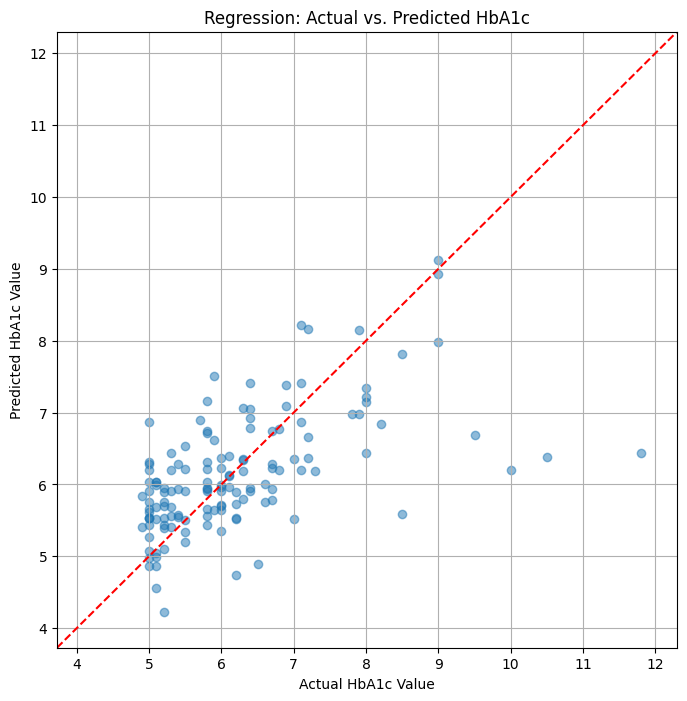

R-squared (Coefficient of Determination): 0.3265

 Regression Task Complete 


In [25]:
# --- Step 11 (Regression): Evaluating Model on Test Set ---
print("\n--- Step 11 (Regression): Evaluating Model on Test Set ---")

if not test_df_reg.empty and 'hba1c_value' in test_df_reg.columns and \
   'model_reg' in locals() and isinstance(model_reg, tf.keras.Model) and \
   tf.data.experimental.cardinality(test_ds_reg).numpy() > 0:

    print("Evaluating regression model...")
    steps_per_epoch_test_reg = math.ceil(len(test_df_reg) / BATCH_SIZE)
    results_reg = model_reg.evaluate(test_ds_reg,
                                     steps=steps_per_epoch_test_reg,
                                     verbose=1,
                                     return_dict=True)

    print("\nRegression Test Set Performance:")
    print(f"  Mean Absolute Error (MAE): {results_reg['mae']:.4f}")
    print(f"  Mean Squared Error (MSE):  {results_reg['mse']:.4f}")
    rmse = math.sqrt(results_reg['mse'])
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")

    print("\nPredicting on test set for scatter plot...")
    y_pred_test_reg = model_reg.predict(test_ds_reg, steps=steps_per_epoch_test_reg, verbose=1)
    if y_pred_test_reg.ndim > 1 and y_pred_test_reg.shape[0] > len(test_df_reg): # Handle padding
         y_pred_test_reg = y_pred_test_reg[:len(test_df_reg)]
    y_pred_test_reg = y_pred_test_reg.squeeze() # Remove single dimension if present

    y_true_test_reg = test_df_reg['hba1c_value'].values

    # Ensure lengths match before plotting
    if len(y_pred_test_reg) == len(y_true_test_reg):
        print("Generating Actual vs. Predicted Scatter Plot...")
        plt.figure(figsize=(8, 8))
        plt.scatter(y_true_test_reg, y_pred_test_reg, alpha=0.5)
        plt.xlabel("Actual HbA1c Value")
        plt.ylabel("Predicted HbA1c Value")
        plt.title("Regression: Actual vs. Predicted HbA1c")
        # Add a line y=x for reference
        min_val = min(np.min(y_true_test_reg), np.min(y_pred_test_reg)) - 0.5
        max_val = max(np.max(y_true_test_reg), np.max(y_pred_test_reg)) + 0.5
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
        plt.xlim(min_val, max_val)
        plt.ylim(min_val, max_val)
        plt.grid(True)
        plt.show()

        # Calculate R-squared (Coefficient of Determination) - Optional but informative
        correlation_matrix = np.corrcoef(y_true_test_reg, y_pred_test_reg)
        correlation_xy = correlation_matrix[0,1]
        r_squared = correlation_xy**2
        print(f"R-squared (Coefficient of Determination): {r_squared:.4f}")

    else:
        print(f"Warning: Length mismatch between true ({len(y_true_test_reg)}) and predicted ({len(y_pred_test_reg)}) values. Cannot generate scatter plot.")

else:
    print("Skipping regression evaluation due to:")
    if 'test_df_reg' not in locals() or test_df_reg.empty: print("- Missing or empty test_df_reg.")
    if 'hba1c_value' not in test_df_reg.columns: print("- Missing 'hba1c_value' in test_df_reg.")
    if 'model_reg' not in locals() or not isinstance(model_reg, tf.keras.Model): print("- Regression model 'model_reg' not defined.")
    if tf.data.experimental.cardinality(test_ds_reg).numpy() == 0: print("- Regression test dataset 'test_ds_reg' is empty or cannot produce data.")


print("\n Regression Task Complete ")

In [26]:
# Saving the  Final Regression Model 
print("\n--- Saving Final Regression Model ---")
final_model_path_reg = os.path.join(checkpoint_dir_reg, 'final_regression_model_hba1c.keras') # Use .keras format
try:
    if 'model_reg' in locals() and isinstance(model_reg, tf.keras.Model):
        model_reg.save(final_model_path_reg)
        print(f"Final regression model saved to {final_model_path_reg}")
    else:
        print("Could not save final model: 'model_reg' not found or not a Keras Model.")
except Exception as e:
    print(f"Error saving final regression model: {e}")


--- Saving Final Regression Model ---
Final regression model saved to /kaggle/working/final_regression_model_hba1c.keras


In [28]:
# Error Analysis - Worst Predictions 
print("\n Error Analysis: Examples with Largest Prediction Errors ")
if 'test_df_reg' in locals() and not test_df_reg.empty and \
   'y_true_test_reg' in locals() and 'y_pred_test_reg' in locals() and \
    len(y_true_test_reg) == len(y_pred_test_reg):

    errors = np.abs(y_true_test_reg - y_pred_test_reg)
    error_df = test_df_reg.copy()
    error_df['predicted_hba1c'] = y_pred_test_reg
    error_df['absolute_error'] = errors

    # Sort by error and take top N
    worst_predictions = error_df.sort_values(by='absolute_error', ascending=False).head(5) # Show top 5

    print("Top 5 Worst Predictions (Largest Absolute Error):")
    print(worst_predictions[['filepath', 'hba1c_value', 'predicted_hba1c', 'absolute_error']])


else:
    print("Could not perform error analysis: Missing necessary dataframes or predictions.")


 Error Analysis: Examples with Largest Prediction Errors 
Top 5 Worst Predictions (Largest Absolute Error):
                                              filepath  hba1c_value  \
675  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Image...         11.8   
752  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Image...         10.5   
972  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Image...         10.0   
666  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Image...          8.5   
432  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Image...          9.5   

     predicted_hba1c  absolute_error  
675         6.443494        5.356506  
752         6.383141        4.116859  
972         6.197425        3.802575  
666         5.589252        2.910748  
432         6.693954        2.806046  


In [32]:
# Ensure these are defined from your main script:
# IMG_SIZE, APPLY_ROI_CROP, APPLY_CLAHE, APPLY_GAUSSIAN_BLUR
# Also ensure the OpenCV helper functions are defined:
# _crop_black_borders_cv, _apply_clahe_cv, _apply_gaussian_blur_cv

def predict_single_image_hba1c(model_to_use, image_path,
                               target_size=IMG_SIZE, # Use the globally defined IMG_SIZE
                               apply_roi=APPLY_ROI_CROP,
                               apply_clahe=APPLY_CLAHE,
                               apply_blur=APPLY_GAUSSIAN_BLUR):
    """
    Loads, preprocesses, and predicts HbA1c for a single image file.
    The model's internal preprocess_input_effnet layer will be applied during model.predict().
    """
    # print(f"--- Debug: Predicting for image: {os.path.basename(image_path)} ---") # Optional debug
    try:
        # 1. Load Image using TensorFlow IO
        img_str = tf.io.read_file(image_path)
        img_decoded = tf.image.decode_image(img_str, channels=3, expand_animations=False)
        if img_decoded.dtype != tf.uint8: img_decoded = tf.cast(img_decoded, tf.uint8)

        # 2. Apply the SAME Custom Preprocessing as during training
        img_processed = img_decoded
        if apply_roi:
            img_processed = tf.py_function(func=_crop_black_borders_cv, inp=[img_processed], Tout=tf.uint8)
            img_processed.set_shape([None, None, 3])
        if apply_clahe:
            img_processed = tf.py_function(func=_apply_clahe_cv, inp=[img_processed], Tout=tf.uint8)
            img_processed.set_shape([None, None, 3])
        if apply_blur:
            img_processed = tf.py_function(func=_apply_gaussian_blur_cv, inp=[img_processed], Tout=tf.uint8)
            img_processed.set_shape([None, None, 3])

        # 3. Resize to model's expected input size
        img_resized = tf.image.resize(img_processed, [target_size, target_size])

        # 4. Cast to float32 (in [0, 255] range before model's internal preprocessing)
        img_final_tensor = tf.cast(img_resized, tf.float32)

        # 5. Add Batch Dimension (model.predict expects a batch)
        img_batch = tf.expand_dims(img_final_tensor, axis=0)

        # 6. Predict
        prediction = model_to_use.predict(img_batch, verbose=0)

        # 7. Extract predicted value
        predicted_value = prediction[0][0]
        return float(predicted_value)

    except tf.errors.NotFoundError:
        print(f"Error (predict_single_image_hba1c): Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"An error occurred during single image prediction for {os.path.basename(image_path)}: {e}")
        return None



In [ ]:
# Interactive Prediction 
print("\n--- Interactive Prediction ---")

# Check if the necessary components exist
if 'model_reg' in locals() and isinstance(model_reg, tf.keras.Model) and \
   'final_labeled_data' in locals() and isinstance(final_labeled_data, pd.DataFrame) and \
   'filepath' in final_labeled_data.columns and 'hba1c_value' in final_labeled_data.columns and \
   'HBA1C_THRESHOLD' in locals(): # Ensure threshold is defined

     while True:
        img_path_input = input("Enter image path (or type 'quit' to exit): ")
        if img_path_input.lower() == 'quit':
            break
        if not os.path.exists(img_path_input):
             print(f"Error: File not found at '{img_path_input}'. Please try again.")
             continue

        # Get the numerical prediction first
        pred_hba1c = predict_single_image_hba1c(model_reg, img_path_input)

        # If prediction was successful, proceed
        if pred_hba1c is not None:
             print(f"\n--- Results for {os.path.basename(img_path_input)} ---")
             print(f"Predicted HbA1c Value: {pred_hba1c:.2f}")

             # --- Classify Predicted Value based on Threshold ---
             classification_threshold = HBA1C_THRESHOLD # Use the existing threshold
             if pred_hba1c > classification_threshold:
                 predicted_class_label = f"Diabetic (> {classification_threshold})"
             else:
                 predicted_class_label = f"Non-Diabetic (<= {classification_threshold})"
             print(f"Classification based on Prediction: {predicted_class_label}")
             # --- End Classification of Predicted Value ---

             # --- Lookup Actual Value ---
             matching_rows = final_labeled_data.loc[final_labeled_data['filepath'] == img_path_input]

             if not matching_rows.empty:
                 actual_hba1c_value = matching_rows['hba1c_value'].iloc[0]
                 print(f"Actual HbA1c Value:           {actual_hba1c_value:.2f}")
                 print(f"Prediction Difference:        {abs(actual_hba1c_value - pred_hba1c):.2f}")

                 # Also classify the actual value for comparison
                 if actual_hba1c_value > classification_threshold:
                     actual_class_label = f"Diabetic (> {classification_threshold})"
                 else:
                     actual_class_label = f"Non-Diabetic (<= {classification_threshold})"
                 print(f"Actual Classification:          {actual_class_label}")

                 if predicted_class_label == actual_class_label:
                    print(f"-> Classification based on prediction AGREES with actual classification.")
                 else:
                    print(f"-> Classification based on prediction DISAGREES with actual classification.")

             else:
                 print(f"Actual HbA1c Value:           Not found in the loaded dataset.")
             # --- End Lookup ---
             print("-" * 20) # Separator for next input

else:
    print("Interactive prediction skipped:")
    if 'model_reg' not in locals() or not isinstance(model_reg, tf.keras.Model):
        print("- Regression model 'model_reg' not available.")
    if 'final_labeled_data' not in locals() or not isinstance(final_labeled_data, pd.DataFrame):
        print("- DataFrame 'final_labeled_data' not available.")
    elif not ('filepath' in final_labeled_data.columns and 'hba1c_value' in final_labeled_data.columns):
        print("- DataFrame 'final_labeled_data' is missing 'filepath' or 'hba1c_value' columns.")
    if 'HBA1C_THRESHOLD' not in locals():
         print("- Variable 'HBA1C_THRESHOLD' is not defined for classification.")


--- Interactive Prediction ---


Enter image path (or type 'quit' to exit):  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF/101.png


E0000 00:00:1747108547.483842      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747108547.621897      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747108547.754791      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



--- Results for 101.png ---
Predicted HbA1c Value: 6.73
Classification based on Prediction: Diabetic (> 6.5)
Actual HbA1c Value:           15.60
Prediction Difference:        8.87
Actual Classification:          Diabetic (> 6.5)
-> Classification based on prediction AGREES with actual classification.
--------------------


Enter image path (or type 'quit' to exit):  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF/172.png


...

Enter image path (or type 'quit' to exit):  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Images/DM(HbA1c_FF)images/HbA1c_FF/105.png



--- Results for 105.png ---
Predicted HbA1c Value: 6.90
Classification based on Prediction: Diabetic (> 6.5)
Actual HbA1c Value:           Not found in the loaded dataset.
--------------------


Enter image path (or type 'quit' to exit):  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF/1.png



--- Results for 1.png ---
Predicted HbA1c Value: 6.93
Classification based on Prediction: Diabetic (> 6.5)
Actual HbA1c Value:           6.80
Prediction Difference:        0.13
Actual Classification:          Diabetic (> 6.5)
-> Classification based on prediction AGREES with actual classification.
--------------------


Enter image path (or type 'quit' to exit):  /kaggle/input/hb1ac-dataset/DM/DM(HbA1c) Images/DM(HbA1c_HF)images/HbA1c_HF/103.png
